In [ ]:
import polars as pl
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
import sklearn
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor



# statsmodels.tsa.exponential_smoothing.ets.ETSModel
# statsmodels.tsa.statespace.structural.UnobservedComponents
# statsmodels.tsa.forecasting.theta.ThetaModel
# GARCH is the classical go-to specifically when volatility (not the mean) is what you're modeling

sns.set_style("darkgrid")

In [2]:
t = 500
sd = 10

slope = 0.1
intercept = 100
amplitude = 20.0
frequency = 100.0

x = np.arange(0, t+1)
trend = slope * x + intercept
noise = norm.rvs(0, sd, t+1)
seasonality = amplitude * np.sin(2 * np.pi * x / frequency)

y = trend + seasonality + noise

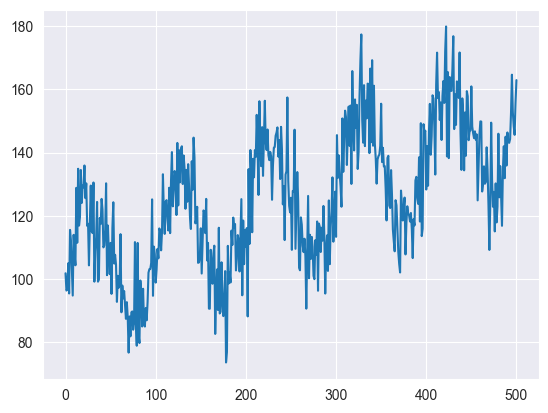

In [3]:
sns.lineplot(x=x, y=y)
plt.show()

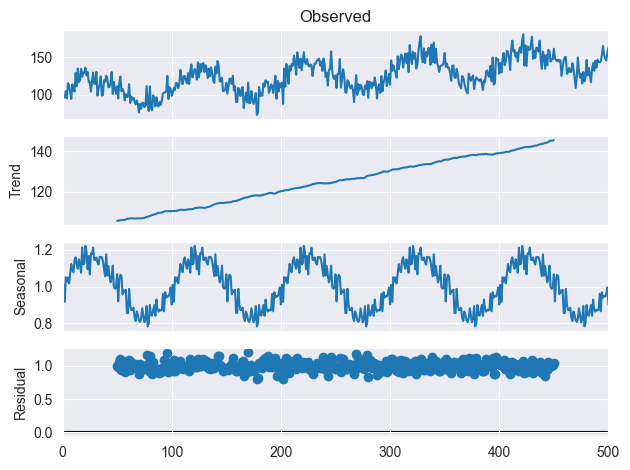

In [4]:
result = seasonal_decompose(y, model='multiplicative', period=100)
result.plot()
plt.show()

In [5]:
season_length = int(frequency)
h = season_length
y_train, y_test = y[:-h], y[-h:]

avg_change = (y_train[-1] - y_train[0]) / (len(y_train) - 1)
forecast = y_train[-season_length:] + avg_change * h

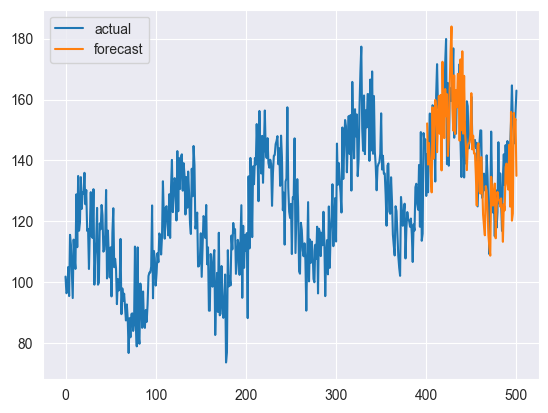

In [6]:
sns.lineplot(x=x, y=y, label="actual")
sns.lineplot(x=x[-h:], y=forecast, label="forecast")
plt.legend()
plt.show()

In [7]:
mae = np.mean(np.abs(y_test - forecast))
rmse = np.sqrt(np.mean((y_test - forecast) ** 2))
mape = np.mean(np.abs((y_test - forecast) / y_test)) * 100

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.2f}%")

MAE:  11.336
RMSE: 14.488
MAPE: 7.71%


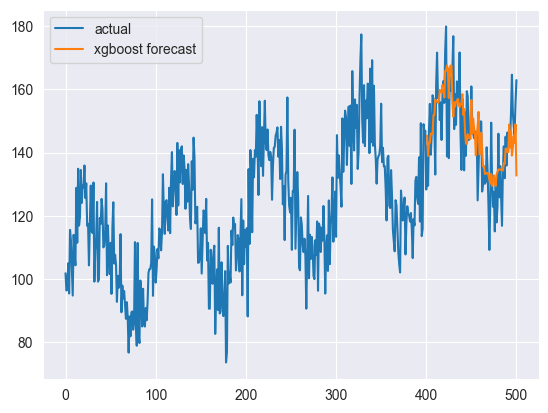

In [ ]:
# XGBoost

h = int(frequency)
x_train, x_test = x[:-h], x[-h:]
y_train, y_test = y[:-h], y[-h:]

def make_features(idx):
    return np.column_stack([
        idx,
        np.sin(2 * np.pi * idx / frequency),
        np.cos(2 * np.pi * idx / frequency),
    ])

model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.1)
model.fit(make_features(x_train), y_train)
forecast = model.predict(make_features(x_test))

sns.lineplot(x=x, y=y, label="actual")
sns.lineplot(x=x_test, y=forecast, label="xgboost forecast")
plt.legend()
plt.show()

In [11]:
mae = np.mean(np.abs(y_test - forecast))
rmse = np.sqrt(np.mean((y_test - forecast) ** 2))
mape = np.mean(np.abs((y_test - forecast) / y_test)) * 100

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.2f}%")

MAE:  8.039
RMSE: 10.660
MAPE: 5.63%


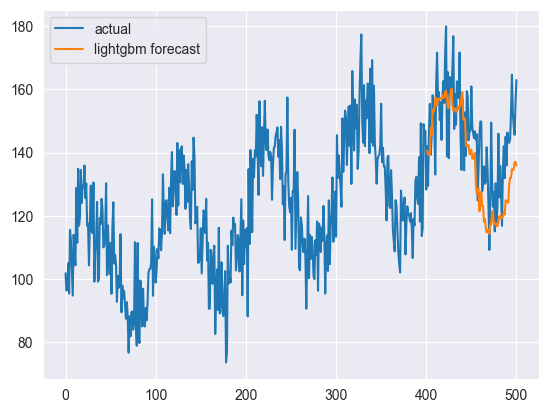

In [13]:
# LightGBM

h = int(frequency)
x_train, x_test = x[:-h], x[-h:]
y_train, y_test = y[:-h], y[-h:]

# --- features: time index (trend) + sin/cos (seasonality) ---
def make_features(idx):
    return np.column_stack([
        idx,
        np.sin(2 * np.pi * idx / frequency),
        np.cos(2 * np.pi * idx / frequency),
    ])

model = LGBMRegressor(n_estimators=200, max_depth=3, learning_rate=0.1, verbose=-1)
model.fit(make_features(x_train), y_train)
forecast = model.predict(make_features(x_test))

# --- plot ---
sns.lineplot(x=x, y=y, label="actual")
sns.lineplot(x=x_test, y=forecast, label="lightgbm forecast")
plt.legend()
plt.show()

In [14]:
mae = np.mean(np.abs(y_test - forecast))
rmse = np.sqrt(np.mean((y_test - forecast) ** 2))
mape = np.mean(np.abs((y_test - forecast) / y_test)) * 100

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.2f}%")

MAE:  11.129
RMSE: 13.632
MAPE: 7.61%


In [10]:
shap

NameError: name 'shap' is not defined

In [ ]:
bullwhip

In [ ]:
# VARIMAX

model = SARIMAX(
    y,
    exog=X,
    order=(p, d, q),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
results = model.fit(disp=False)

In [ ]:
# SARIMAX

model = SARIMAX(
    y,
    exog=X,
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    enforce_stationarity=False,
    enforce_invertibility=False,
)